# 🧠 5.3 BiLSTM Classification Model & Hyperparameter Tuning

Este notebook entrena clasificadores basados en **Redes Neuronales LSTM Bidireccionales (BiLSTM)** para la clasificación binaria sobre los embeddings generados por ProtFlash. A diferencia de un MLP o una CNN, un BiLSTM puede modelar dependencias secuenciales a lo largo de la secuencia, leyendo los embeddings por residuo en ambas direcciones y agregando las salidas mediante *pooling* antes de combinarlas con el embedding global.

---

## 📋 Descripción general

El modelo recibe tres entradas:

- `X`: embeddings por residuo, con forma `(B, L, 768)`.
- `G`: embedding global/contextual de la secuencia, con forma `(B, 768)`.
- `M`: máscara binaria, con forma `(B, L)`, usada para ignorar posiciones de padding.

La arquitectura `MeanBiLSTMClassifier`:

1. Procesa los embeddings por residuo `X` con una red **BiLSTM**, respetando las longitudes reales de las secuencias mediante `pack_padded_sequence`.
2. Recupera las salidas del BiLSTM con `pad_packed_sequence` y aplica la máscara `M` para ignorar posiciones de padding.
3. Agrega las salidas del BiLSTM mediante:
   - *max pooling* enmascarado.
   - *average pooling* enmascarado.
4. Concatena las características agregadas del BiLSTM con el embedding global `G`.
5. Procesa la representación combinada a través de capas `Linear`, `BatchNorm1d`, activación `GELU` y `Dropout`.
6. Finaliza con una capa lineal que produce los logits para la clasificación binaria.

---

## 🛠️ Funcionalidades principales

1. **Arquitectura del modelo**
   - Clasificador basado en `BiLSTM` con procesamiento bidireccional de la secuencia.
   - Agregación de las salidas del BiLSTM mediante *max pooling* y *average pooling* enmascarados.
   - Combinación con el embedding global `G` para la clasificación final.

2. **Entrenamiento y optimización**
   - Optimizador `AdamW` con *weight decay*.
   - Función de pérdida `FocalLoss`, basada en `binary_cross_entropy_with_logits`, para manejar el desbalance de clases.
   - `ReduceLROnPlateau` para ajustar la tasa de aprendizaje durante el entrenamiento.
   - *Early stopping* basado en la pérdida de validación.

3. **Búsqueda de hiperparámetros**
   - Evaluación de tres configuraciones: `BiLSTM_Small`, `BiLSTM_Medium` y `BiLSTM_Large`.
   - Variación del tamaño oculto del BiLSTM, número de capas y *dropout*.

4. **Monitoreo y registro**
   - Registro por época de pérdida de entrenamiento/validación, accuracy, MCC y ROC-AUC.
   - Guardado automático del mejor modelo según la menor pérdida de validación.
   - Exportación del historial de entrenamiento en CSV y de las métricas de validación en JSON.

## 📦 Importación de dependencias y entorno

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de rutas e hiperparámetros BiLSTM

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/new-final-dataset") 
OUT_DIR = Path("/kaggle/working/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT = DATA_DIR / "train_dataset.pt"
VAL_PT   = DATA_DIR / "val_dataset.pt"

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 128
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
INPUT_DIM   = 768      # Dimensión de los embeddings

# ========== ARCHITECTURAS A COMPARAR ==========
ARCHITECTURES = [
    {
        "name": "BiLSTM_Small",
        "hidden_size": 128,
        "num_layers": 1,
        "mlp_hidden": [128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "BiLSTM_Medium",
        "hidden_size": 256,
        "num_layers": 2,
        "mlp_hidden": [128],
        "dropout": 0.4,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "BiLSTM_Large",
        "hidden_size": 512,
        "num_layers": 2,
        "mlp_hidden": [256, 128],
        "dropout": 0.5,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

print(f"Architectures to compare: {len(ARCHITECTURES)}")
for cfg in ARCHITECTURES:
    print(f"  - {cfg['name']}: hidden={cfg['hidden_size']}, layers={cfg['num_layers']}, dropout={cfg['dropout']}")

Architectures to compare: 3
  - BiLSTM_Small: hidden=128, layers=1, dropout=0.3
  - BiLSTM_Medium: hidden=256, layers=2, dropout=0.4
  - BiLSTM_Large: hidden=512, layers=2, dropout=0.5


## 🖥️ Semilla para reproducibilidad y detección de dispositivo

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## 📂 Definición de la clase `AMPDataset`

In [4]:
class AMPDataset(Dataset):
    """
    Dataset for training the AMP classifier with Gated Pooling.

    Returns:
        X:     torch.FloatTensor (L_max, 768)    — ProtFlash embeddings
        G:     torch.FloatTensor (768,)          — Global/CLS context embedding
        M:     torch.FloatTensor (L_max,)        — binary mask
        y:     torch.FloatTensor (1,)            — label
    """
    def __init__(self, X, G, M, labels):
        self.X = torch.from_numpy(X).float()          # (N, 100, 768)
        self.G = torch.from_numpy(G).float()          # (N, 768)
        self.M = torch.from_numpy(M).float()          # (N, 100)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (100, 768)
            "G": self.G[idx],           # (768,)
            "M": self.M[idx],           # (100,)
            "y": self.y[idx]            # (1,)
        }

## 💾 Función de carga de datasets pre-serializados

In [5]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## 📥 Carga de splits de entrenamiento y validación

In [6]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13766 muestras
   val_ds  : 4128 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   y: str = 'y'


## 🤝 Función de colación (`collate_fn`)

In [7]:
def collate_fn(batch):
    if isinstance(batch[0], dict):
        embeddings = torch.stack([item['X'] for item in batch], dim=0)
        globals_emb = torch.stack([item['G'] for item in batch], dim=0) 
        masks       = torch.stack([item['M'] for item in batch], dim=0)
        labels      = torch.stack([item['y'] for item in batch], dim=0)
    else:
        raise TypeError(f"Batch fallido")
    return embeddings, globals_emb, masks, labels

## 🚚 Creación de DataLoaders

In [8]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, y_b = next(iter(train_loader))
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)}")


✅ Batches: train=108, val=33
   ✅ X_b: (128, 100, 768) | G_b: (128, 768)


## 🔑 Mecanismo `MeanPooler`

In [9]:
class MeanPooler(nn.Module):
    """
    Mean pooling simple con máscara.
    
    Input:
      - X: (B, L, D) embeddings por residuo
      - M: (B, L) máscara binaria (1 = residuo válido, 0 = padding)
    
    Output:
      - E: (B, D) embedding agregado por secuencia
    """
    def __init__(self, input_dim: int):
        super().__init__()
        # No hay parámetros aprendibles

    def forward(self, X: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        mask = M.unsqueeze(-1)                        # (B, L, 1)
        summed = (X * mask).sum(dim=1)               # (B, D)
        counts = mask.sum(dim=1).clamp(min=1e-8)     # (B, 1)
        return summed / counts                        # (B, D)

## 🏗️ Arquitectura `BiLSTMClassifier` y Verificación

In [10]:
class MeanBiLSTMClassifier(nn.Module):
    """BiLSTM classifier con Mean Pooling (sin gating por residuo)."""

    def __init__(self, input_dim: int, hidden_size: int, num_layers: int,
                 mlp_hidden: List[int], dropout: float = 0.3):
        super().__init__()

        self.pooler = MeanPooler(input_dim=input_dim)

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # lstm_out_dim = hidden_size * 4 (max_pool + avg_pool de forward/backward)
        lstm_out_dim = hidden_size * 4
        clf_in_dim = lstm_out_dim + input_dim  # + G global

        layers = []
        for h_dim in mlp_hidden:
            layers.append(nn.Linear(clf_in_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout))
            clf_in_dim = h_dim

        self.mlp = nn.Sequential(*layers)
        self.classifier = nn.Linear(clf_in_dim, 1)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        lengths = M.sum(dim=1).clamp(min=1).cpu()

        packed = pack_padded_sequence(X, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=X.size(1))

        # Pooling sobre salida del LSTM
        mask = M.unsqueeze(-1).bool()
        max_pool = lstm_out.masked_fill(~mask, -1e9).max(dim=1)[0]
        avg_pool = (lstm_out.masked_fill(~mask, 0.0).sum(dim=1)
                    / M.sum(dim=1, keepdim=True).clamp(min=1e-8))

        lstm_features = torch.cat([max_pool, avg_pool], dim=1)

        combined = torch.cat([lstm_features, G], dim=1)
        x = self.mlp(combined)
        return self.classifier(x)


def build_mean_lstm_model(config: Dict, input_dim: int) -> nn.Module:
    return MeanBiLSTMClassifier(
        input_dim, config["hidden_size"], config["num_layers"],
        config["mlp_hidden"], config["dropout"],
    )

## 📐 Helper: `sigmoid_np`

In [11]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [12]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    """Return (probabilities, true_labels) from a DataLoader."""
    model.eval()
    logits_list, y_list = [], []
    
    for batch in loader:
        # Desempaquetar los 4 tensores (X, G, M, y)
        Xb, Gb, Mb, yb = [b.to(device) for b in batch]
        
        # Pasamos los 3 tensores de entrada
        logits = model(Xb, Gb, Mb)
        
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
        
    logits_all = np.concatenate(logits_list)
    y_all = np.concatenate(y_list)
    return sigmoid_np(logits_all), y_all

## 📏 Cálculo de Métricas de Clasificación

In [13]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [14]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [15]:
def train_model(config, input_dim, train_loader, val_loader, device,
                max_epochs=MAX_EPOCHS, patience=PATIENCE):

    seed_everything(SEED)

    model = build_mean_lstm_model(config, input_dim).to(device)

    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": [], "val_roc_auc": []}

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    no_improve = 0

    for epoch in range(1, max_epochs + 1):

        # ================= TRAIN =================
        model.train()

        train_loss = 0.0
        n = 0

        for Xb, Gb, Mb, yb in train_loader:

            Xb = Xb.to(device)
            Gb = Gb.to(device)
            Mb = Mb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()

            logits = model(Xb, Gb, Mb)

            loss = criterion(logits, yb)
            

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)

        train_loss /= n

        # ================= VALIDATION =================
        model.eval()

        val_loss = 0.0
        n = 0

        with torch.no_grad():

            for Xb, Gb, Mb, yb in val_loader:

                Xb = Xb.to(device)
                Gb = Gb.to(device)
                Mb = Mb.to(device)
                yb = yb.to(device)

                logits = model(Xb, Gb, Mb)

                loss = criterion(logits, yb)

                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)

        val_loss /= n

        scheduler.step(val_loss)

        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); 
        history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])
        history["val_roc_auc"].append(v_met["roc_auc"])

        if val_loss < best_val_loss - MIN_DELTA:

            best_val_loss = val_loss
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

            best_epoch = epoch
            no_improve = 0

        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
    }

## 🔬 Ejecución Secuencial de Arquitecturas

In [16]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    n_params = sum(p.numel() for p in res["model"].parameters())

    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({
        "model_name": config["name"],
        "state_dict": res["model"].state_dict(),
        "config": config,
        "input_dim": INPUT_DIM
    }, ckpt_path)

    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "model": res["model"],
        "config": config,
        "history": res["history"],
    })

    
    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_roc_auc={v_metrics.get('roc_auc', 0.0):.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)


--- Entrenando BiLSTM_Small ---
E01 | TL: 0.0594 | VL: 0.0525 | Val MCC: 0.7752 | B_ep: 1
E02 | TL: 0.0482 | VL: 0.0494 | Val MCC: 0.7855 | B_ep: 2
E03 | TL: 0.0431 | VL: 0.0496 | Val MCC: 0.7889 | B_ep: 2
E04 | TL: 0.0386 | VL: 0.0489 | Val MCC: 0.7924 | B_ep: 4
E05 | TL: 0.0355 | VL: 0.0533 | Val MCC: 0.8056 | B_ep: 4
E06 | TL: 0.0327 | VL: 0.0550 | Val MCC: 0.8122 | B_ep: 4
E07 | TL: 0.0301 | VL: 0.0497 | Val MCC: 0.8039 | B_ep: 4
E08 | TL: 0.0284 | VL: 0.0541 | Val MCC: 0.8057 | B_ep: 4
E09 | TL: 0.0269 | VL: 0.0524 | Val MCC: 0.8060 | B_ep: 4
E10 | TL: 0.0238 | VL: 0.0562 | Val MCC: 0.8120 | B_ep: 4
E11 | TL: 0.0165 | VL: 0.0565 | Val MCC: 0.8167 | B_ep: 4
E12 | TL: 0.0119 | VL: 0.0684 | Val MCC: 0.8134 | B_ep: 4
E13 | TL: 0.0109 | VL: 0.0744 | Val MCC: 0.8227 | B_ep: 4
E14 | TL: 0.0086 | VL: 0.0780 | Val MCC: 0.7840 | B_ep: 4
E15 | TL: 0.0072 | VL: 0.0819 | Val MCC: 0.8209 | B_ep: 4
E16 | TL: 0.0062 | VL: 0.0798 | Val MCC: 0.8221 | B_ep: 4

  ✅ BiLSTM_Small: params=1,083,905 | b

## 📊 Tabla Resumen y Ranking de Modelos

In [17]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)

print("\n" + "=" * 100)
print("ARCHITECTURE COMPARISON (sorted by Val MCC)")
print("=" * 100)
print(summary_df.to_string())
print("=" * 100)

summary_df.to_csv(OUT_DIR / "lstm_architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


ARCHITECTURE COMPARISON (sorted by Val MCC)
           Model    Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC
0  BiLSTM_Medium   3908097           4  0.047338  0.903585  0.891671  0.809332     0.959936    0.964786
1   BiLSTM_Large  12305665           4  0.049261  0.897287  0.891003  0.793904     0.961967    0.966816
2   BiLSTM_Small   1083905           4  0.048892  0.896560  0.887956  0.792370     0.961458    0.966093

Saved

🏆 Best model: BiLSTM_Medium


## 📈 Visualización: Curvas de Entrenamiento Individuales

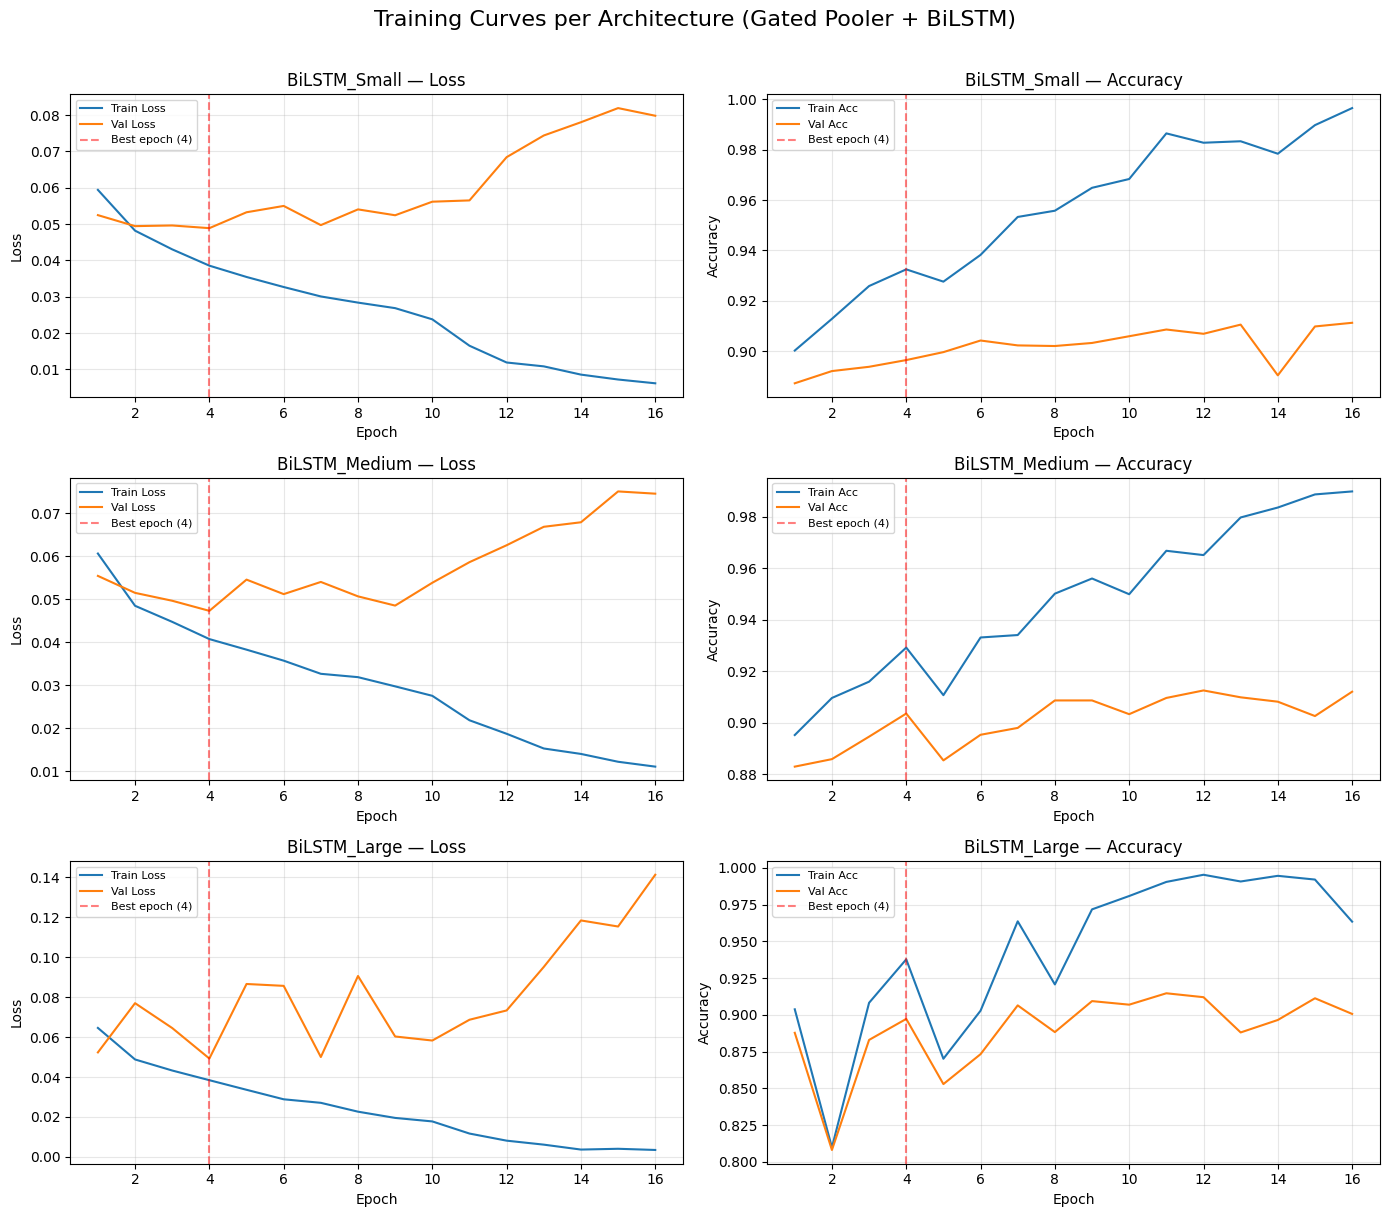

Saved: /kaggle/working/training_curves_individual.png


In [18]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({r['best_epoch']})")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler + BiLSTM)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Curvas comparativas conjuntas

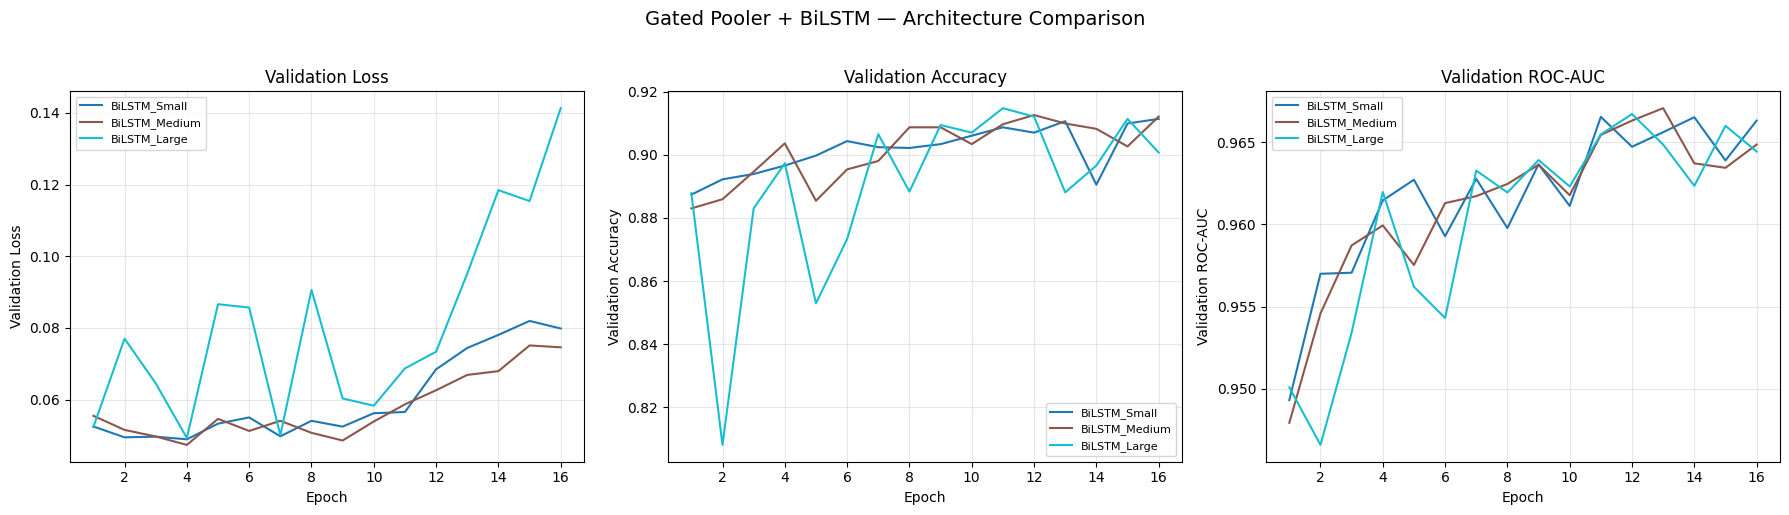

Saved: /kaggle/working/training_curves_comparison.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_roc_auc"], label=r["name"], color=colors[idx], linewidth=1.5)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation Accuracy"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Validation ROC-AUC"); axes[2].set_title("Validation ROC-AUC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler + BiLSTM — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

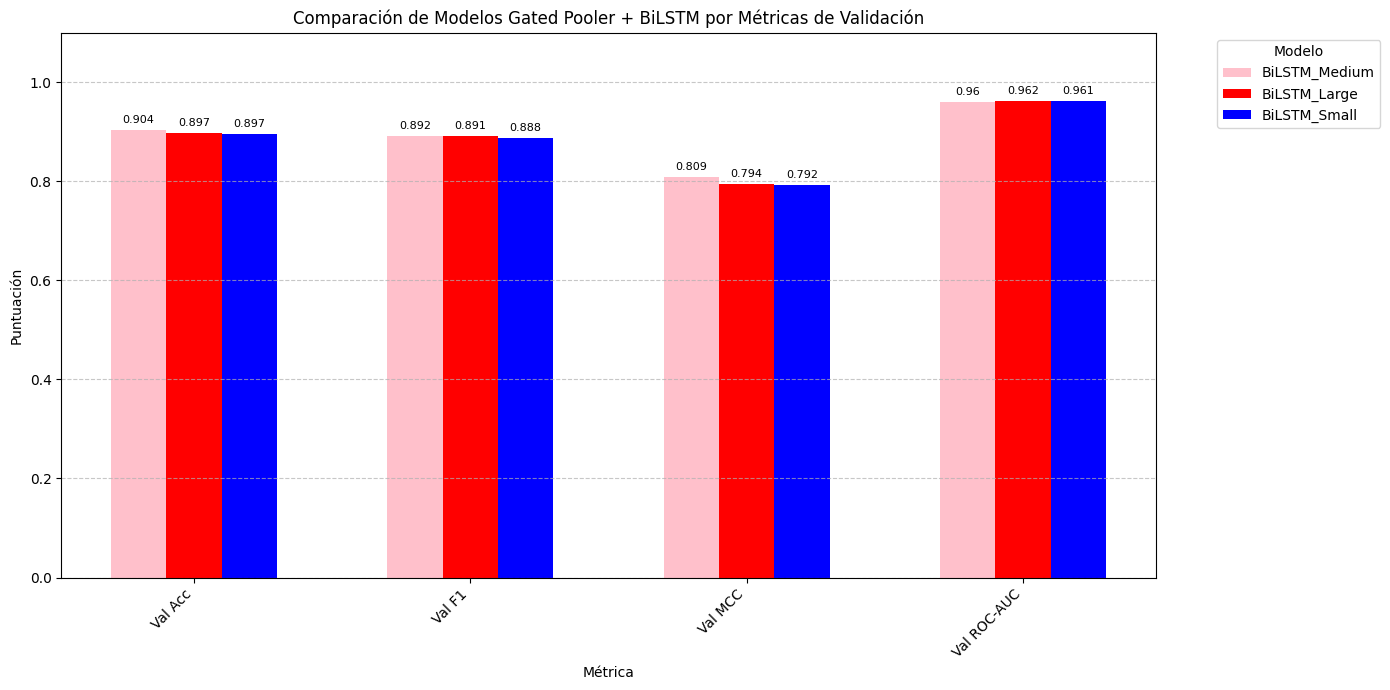

Saved: /kaggle/working/model_metrics_comparison_bar_chart.png


In [20]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['pink', 'red', 'blue', 'violet']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler + BiLSTM por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [21]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: BiLSTM_Medium
   Parameters: 3,908,097
   Best epoch: 4
   Val loss:   0.047338

Saved:
  Checkpoint:    /kaggle/working/best_model_final.pth
  Training log:  /kaggle/working/best_model_training_log.csv
  Val metrics:   /kaggle/working/best_model_val_metrics.json


## 🏆 Conclusión: el mejor modelo

Tras completar el proceso de experimentación, se concluye que la configuración **BiLSTM_Medium** ofrece el mejor rendimiento entre las arquitecturas BiLSTM evaluadas, según la métrica de validación **MCC**.

### Resultados destacados

| Métrica       | Valor  |
|---------------|--------|
| Mejor modelo  | BiLSTM_Medium |
| Parámetros    | 3,908,097 |
| Mejor época   | 4 |
| Val loss      | 0.0473 |
| Val Accuracy  | 0.9036 |
| Val F1        | 0.8917 |
| Val MCC       | 0.8093 |
| Val ROC-AUC   | 0.9599 |
| Val PR-AUC    | 0.9648 |

### Análisis

- **Capacidad de aprendizaje:** el modelo logra converger en pocas épocas gracias a la calidad de los embeddings de 768 dimensiones, alcanzando un buen rendimiento desde etapas tempranas del entrenamiento.
- **Generalización:** la configuración `BiLSTM_Medium`, con un tamaño oculto intermedio y `dropout` de 0.4, logra el mejor equilibrio entre capacidad de modelado y control del sobreajuste.
- **Eficiencia:** aunque `BiLSTM_Small` es más ligero, `BiLSTM_Medium` alcanza el mejor MCC. Por su parte, `BiLSTM_Large` aumenta considerablemente el número de parámetros sin mejorar la métrica principal, por lo que no justifica su mayor costo computacional.

**Estado final:** el modelo ha sido exportado como `best_model_final.pth`, quedando listo para su despliegue en producción o integración en herramientas de análisis bioinformático.